In [7]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.lib.stride_tricks import sliding_window_view
from PIL import Image

### Cap 3.6 - Filtros espaciais de aguçamento

##### 3.6.1 - Fundamentos

Derivada de primeira ordem de uma função unidimensional f(x):

$ \frac{\partial f}{\partial x} = f(x+1)-f(x) $

Derivada se segunda ordem de f(x):

$ \frac{\partial^{2} f}{\partial x^{2}} = f(x+1)+f(x-1)-2f(x) $

Implementação do Laplaciano discreto de duas variáveis (sem ajuste):

> 📝: **Note:** O laplaciano discreto é nada mais nada menos que é uma função de duas variáveis de segunda ordem 

$ \nabla2 f = f(x + 1, y) + f(x −1, y) + f(x ,y + 1) + f(x ,y −1) − 4f(x ,y ) $

Com ajuste:

$ g(x, y) = f(x, y) + c[\nabla^2f(x,y)] $

In [8]:
LAPLACE4 = np.array([[0, 1, 0],
                     [1,-4, 1],
                     [0, 1, 0]], dtype=float)

LAPLACE8 = np.array([[1, 1, 1],
                     [1,-8, 1],
                     [1, 1, 1]], dtype=float)

def laplacian_numpy(img, laplace, pad_mode="reflect"):
    """img: HxW ou HxWxC; retorna float64"""
    img = np.asarray(img, dtype=float)
    if img.ndim == 2:      # grayscale
        return _conv2_valid_pad(img, laplace, pad_mode)
    elif img.ndim == 3:    # RGB/RGBA
        chans = [ _conv2_valid_pad(img[...,c], laplace, pad_mode) for c in range(img.shape[2]) ]
        return np.stack(chans, axis=2)
    else:
        raise ValueError("Imagem deve ser 2D (HxW) ou 3D (HxWxC).")

def _conv2_valid_pad(gray, kernel, pad_mode):
    kh, kw = kernel.shape
    ph, pw = kh//2, kw//2
    gp = np.pad(gray, ((ph,ph),(pw,pw)), mode=pad_mode)
    # janelas (H, W, kh, kw)
    win = sliding_window_view(gp, (kh, kw))
    return np.tensordot(win, kernel, axes=((-1,-2),(1,0)))  # mesma forma de gray

In [9]:
img_moon = Image.open("./Fig0338(a)(blurry_moon).tif").convert("L")

In [10]:
img_moon_array = np.array(img_moon)
print(f"{type(img_moon_array)}, {type(img_moon)}")
print(f"{img_moon_array.shape}, {img_moon.size}")

<class 'numpy.ndarray'>, <class 'PIL.Image.Image'>
(540, 466), (466, 540)


In [11]:
# Normalização 
img_moon_normalized = img_moon_array.astype(np.float32) / 255.0
img_moon_float = img_moon_array.astype(np.float32)

moon_image_laplacian_4 = laplacian_numpy(img_moon_normalized, laplace=LAPLACE4) * 255.0 #np.float32
moon_image_laplacian_8 = laplacian_numpy(img_moon_normalized, laplace=LAPLACE8) * 255.0 #np.float32
moon_image_laplacian_adjust = img_moon_float - moon_image_laplacian_4
moon_image_laplacian_adjust_8 = img_moon_float - moon_image_laplacian_8

In [12]:
# Aplica o deslocamento de 128
moon_image_laplacian_4_deslocado = moon_image_laplacian_4 + 128

In [13]:
# Limitar (Clip) e Converter para 8-bit (uint8) para visualização, pois os valores podem estar
# fora da faixa [0, 255] após a subtração

# Clipa e converte para uint8 para exibição (Figura C)
moon_image_laplacian_4_deslocado = np.clip(moon_image_laplacian_4_deslocado, 0, 255).astype(np.uint8)
moon_image_adjust_4 = np.clip(moon_image_laplacian_adjust, 0, 255).astype(np.uint8)
moon_image_laplacian_4_without_adjust = np.clip(moon_image_laplacian_4, 0, 255).astype(np.uint8)
moon_image_adjust_8 = np.clip(moon_image_laplacian_adjust_8, 0, 255).astype(np.uint8)

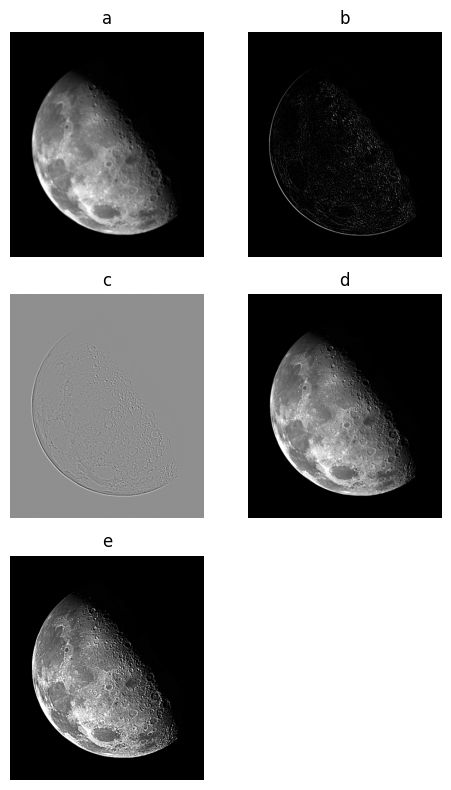

In [16]:
fig, axes = plt.subplots(3,2, figsize=(5,8))

axes[0,0].imshow(img_moon_array, cmap="gray")
axes[0,0].set_title('a')
axes[0,0].axis("off")

axes[0,1].imshow(moon_image_laplacian_4_without_adjust, cmap="gray")
axes[0,1].set_title('b')
axes[0,1].axis("off")

axes[1,0].imshow(moon_image_laplacian_4_deslocado, cmap="gray")
axes[1,0].set_title('c')
axes[1,0].axis("off")

axes[1,1].imshow(moon_image_adjust_4, cmap="gray")
axes[1,1].set_title('d')
axes[1,1].axis("off")

axes[2,0].imshow(moon_image_adjust_8, cmap="gray")
axes[2,0].set_title('e')
axes[2,0].axis("off")

axes[2, 1].set_visible(False)

plt.tight_layout()
plt.savefig("panel_project_2.png")
plt.show()